In [90]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

In [91]:
df= pd.read_csv("hiring.csv")

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   experience         8 non-null      int64  
 1   testscore/10       8 non-null      float64
 2   interviewscore/10  8 non-null      int64  
 3   salary             8 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 388.0 bytes


In [109]:
df.describe()

,experience,testscore/10,interviewscore/10,salary
count,8.000000,8.000000,8.000000,8.00000
mean,3.375000,6.875000,7.875000,63000.00000
std,2.263846,3.044316,1.642081,11501.55269
min,0.000000,0.000000,6.000000,45000.00000
25%,1.750000,6.750000,6.750000,57500.00000
50%,3.500000,7.500000,7.500000,63500.00000
75%,5.250000,8.250000,9.250000,70500.00000
max,6.000000,10.000000,10.000000,80000.00000


In [92]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [93]:
le=LabelEncoder()  
dfle=df
dfle.experience= le.fit_transform(dfle.experience)
dfle

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,6,8.0,9,50000
1,6,8.0,6,45000
2,1,6.0,7,60000
3,5,10.0,10,65000
4,2,9.0,6,70000
5,4,7.0,10,62000
6,3,NaN,7,72000
7,0,7.0,8,80000


In [94]:
df=df.rename(columns={'test_score(out of 10)':'testscore/10','interview_score(out of 10)':'interviewscore/10','salary($)':'salary'})

In [95]:
df

,experience,testscore/10,interviewscore/10,salary
0,6,8.0,9,50000
1,6,8.0,6,45000
2,1,6.0,7,60000
3,5,10.0,10,65000
4,2,9.0,6,70000
5,4,7.0,10,62000
6,3,NaN,7,72000
7,0,7.0,8,80000


In [96]:
df['testscore/10']=df['testscore/10'].fillna(0)
df

,experience,testscore/10,interviewscore/10,salary
0,6,8.0,9,50000
1,6,8.0,6,45000
2,1,6.0,7,60000
3,5,10.0,10,65000
4,2,9.0,6,70000
5,4,7.0,10,62000
6,3,0.0,7,72000
7,0,7.0,8,80000


In [97]:
x=df.drop('salary',axis='columns')
x

,experience,testscore/10,interviewscore/10
0,6,8.0,9
1,6,8.0,6
2,1,6.0,7
3,5,10.0,10
4,2,9.0,6
5,4,7.0,10
6,3,0.0,7
7,0,7.0,8


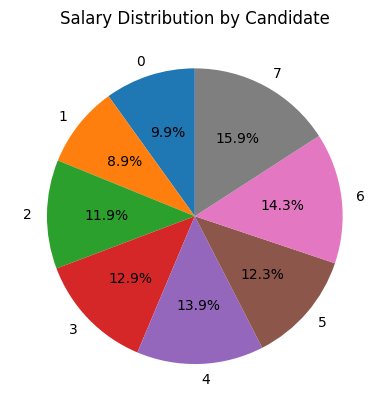

In [120]:
import matplotlib.pyplot as plt

plt.pie(df['salary'], labels=df.index, autopct='%1.1f%%', startangle=90)
plt.title('Salary Distribution by Candidate')
plt.show()


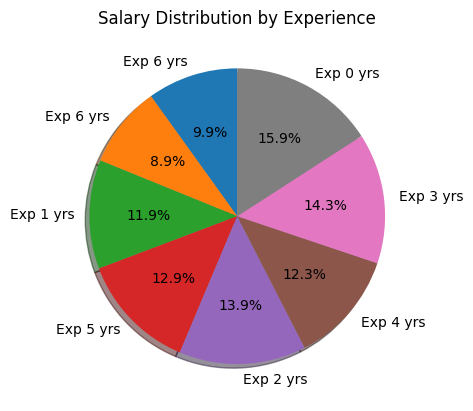

In [121]:
labels = [f"Exp {exp} yrs" for exp in df['experience']]

plt.pie(df['salary'], labels=labels, autopct='%1.1f%%', startangle=90, shadow=True)
plt.title('Salary Distribution by Experience')
plt.show()

In [98]:
df

,experience,testscore/10,interviewscore/10,salary
0,6,8.0,9,50000
1,6,8.0,6,45000
2,1,6.0,7,60000
3,5,10.0,10,65000
4,2,9.0,6,70000
5,4,7.0,10,62000
6,3,0.0,7,72000
7,0,7.0,8,80000


In [99]:
y=df.salary
y

0    50000
1    45000
2    60000
3    65000
4    70000
5    62000
6    72000
7    80000
Name: salary, dtype: int64

In [100]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [101]:
# Create polynomial features (e.g., degree 2)
poly = PolynomialFeatures(degree=2)

In [102]:
#X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Example feature
#y = np.array([2, 5, 10, 17, 26])              # Example target

X_poly = poly.fit_transform(x)

In [103]:
model = LinearRegression()
model.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
y_pred = model.predict(X_poly)

In [105]:
y_pred

array([50000., 45000., 60000., 65000., 70000., 62000., 72000., 80000.])

In [107]:
model.score(X_poly,y)*100

100.0